In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.decomposition import PCA

In [5]:
block_weights_file = "moe_stats.json"

In [6]:
with open(block_weights_file, "r") as f:
    block_weights = json.load(f)

In [10]:
prompts = ["How large is the volume covered by {label}?",
           "Which region(s) of the brain is {label} located in?",
           "What is the shape of {label}?",
           "How spread out is {label}?",
           "How large is the volume of {label} and where is it located?",
           "How large is the volume of {label} and what is its shape?",
           "How large is the volume of {label} and how spread out is it?",
           "In which region is {label} and what is its shape?",
           "In which region is {label} and how spread out is it?",
           "What is the shape of {label} and how spread out is it?",
           "What is the volume, region, and shape of {label}?",
           "What is the volume, region, and spread of {label}?",
           "What is the volume, shape, and spread of {label}?",
           "What is the region, shape, and spread of {label}?",
           "What is the volume, region, shape, and spread of {label}?"]
prompts = [prompt.format(label=label) for label in ["Non-Enhancing Tumor",
                                                    "Surrounding Non-enhancing FLAIR hyperintensity",
                                                    "Enhancing Tissue", 
                                                    "Resection Cavity"] 
           for prompt in prompts]

In [15]:
results = []

In [18]:
for prompt_index in range(len(prompts)):
    prompt = prompts[prompt_index]
    results.append((prompt, [block_wts[prompt_index] for block_name,block_wts in block_weights.items()]))

In [31]:
results

[('How large is the volume covered by Non-Enhancing Tumor?',
  [0.07660723477602005,
   0.08840764313936234,
   0.030268114060163498,
   0.055560871958732605,
   0.030624063685536385,
   0.027022501453757286,
   0.0556095615029335,
   0.07725247740745544,
   0.03607935458421707,
   0.027891159057617188,
   0.06483294814825058,
   0.07252272218465805,
   0.16009490191936493,
   0.07088889181613922,
   0.056846048682928085,
   0.06949152797460556]),
 ('Which region(s) of the brain is Non-Enhancing Tumor located in?',
  [0.0658622682094574,
   0.0782279297709465,
   0.03484487906098366,
   0.0637817457318306,
   0.0435529500246048,
   0.03661568835377693,
   0.06933584064245224,
   0.07368326187133789,
   0.04940293729305267,
   0.03764341026544571,
   0.06801122426986694,
   0.07319014519453049,
   0.10757572948932648,
   0.06258106976747513,
   0.06448713690042496,
   0.0712037980556488]),
 ('What is the shape of Non-Enhancing Tumor?',
  [0.06420492380857468,
   0.07220721989870071,
   

In [29]:
top_k = 3
argmax_results = [(prompt, np.argsort(block_wts)[-top_k:][::-1]) for (prompt, block_wts) in results]

In [30]:
argmax_results

[('How large is the volume covered by Non-Enhancing Tumor?',
  array([12,  1,  7])),
 ('Which region(s) of the brain is Non-Enhancing Tumor located in?',
  array([12,  1,  7])),
 ('What is the shape of Non-Enhancing Tumor?', array([12, 15,  7])),
 ('How spread out is Non-Enhancing Tumor?', array([13, 15, 12])),
 ('How large is the volume of Non-Enhancing Tumor and where is it located?',
  array([12,  1,  0])),
 ('How large is the volume of Non-Enhancing Tumor and what is its shape?',
  array([12,  1, 15])),
 ('How large is the volume of Non-Enhancing Tumor and how spread out is it?',
  array([12, 13, 15])),
 ('In which region is Non-Enhancing Tumor and what is its shape?',
  array([12, 15,  7])),
 ('In which region is Non-Enhancing Tumor and how spread out is it?',
  array([13, 15, 12])),
 ('What is the shape of Non-Enhancing Tumor and how spread out is it?',
  array([15, 13, 10])),
 ('What is the volume, region, and shape of Non-Enhancing Tumor?',
  array([12,  1, 15])),
 ('What is th

In [40]:
results_ = results[:15] + results[30:45] + results[15:30]+ results[45:]
prompts  = [t[0]           for t in results_]
weights  = np.array([t[1]  for t in results_], dtype=float)   # (N,16)
# re-order results so enhancing tissue is in front of the other 

# ------------------------------------------------------------------
# 3 .  (Optional) row clustering to group similar weight profiles
# ------------------------------------------------------------------
row_order       = leaves_list(linkage(weights, method='ward'))
weights_sorted  = weights[row_order]
prompts_sorted  = [prompts[i] for i in row_order]

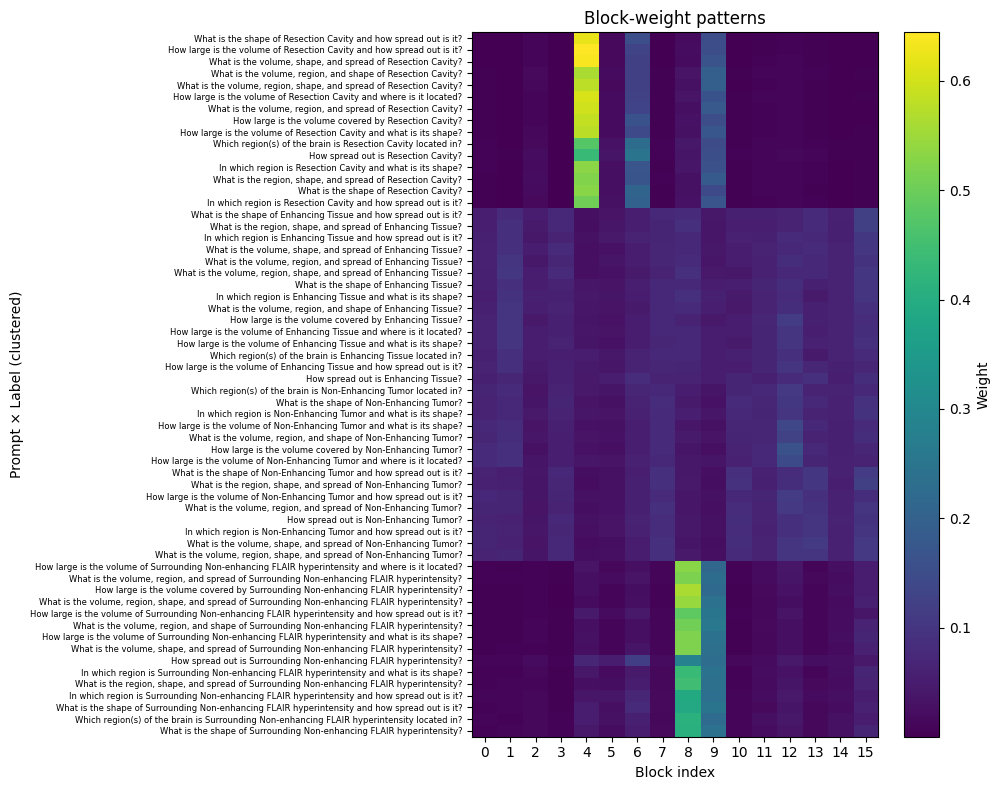

In [41]:
# ------------------------------------------------------------------
# 4 .  Raw‑weight heat‑map  -------------------------------------------------
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))      # one chart only (rules!)
im = ax.imshow(weights_sorted, aspect='auto')
ax.set_xticks(np.arange(16))
ax.set_xticklabels(np.arange(16))
ax.set_yticks(np.arange(len(prompts_sorted)))
ax.set_yticklabels(prompts_sorted, fontsize=6)   # long names → small font
ax.set_xlabel('Block index')
ax.set_ylabel('Prompt × Label (clustered)')
ax.set_title('Block‑weight patterns')
fig.colorbar(im, ax=ax, label='Weight')
plt.tight_layout()
plt.show()

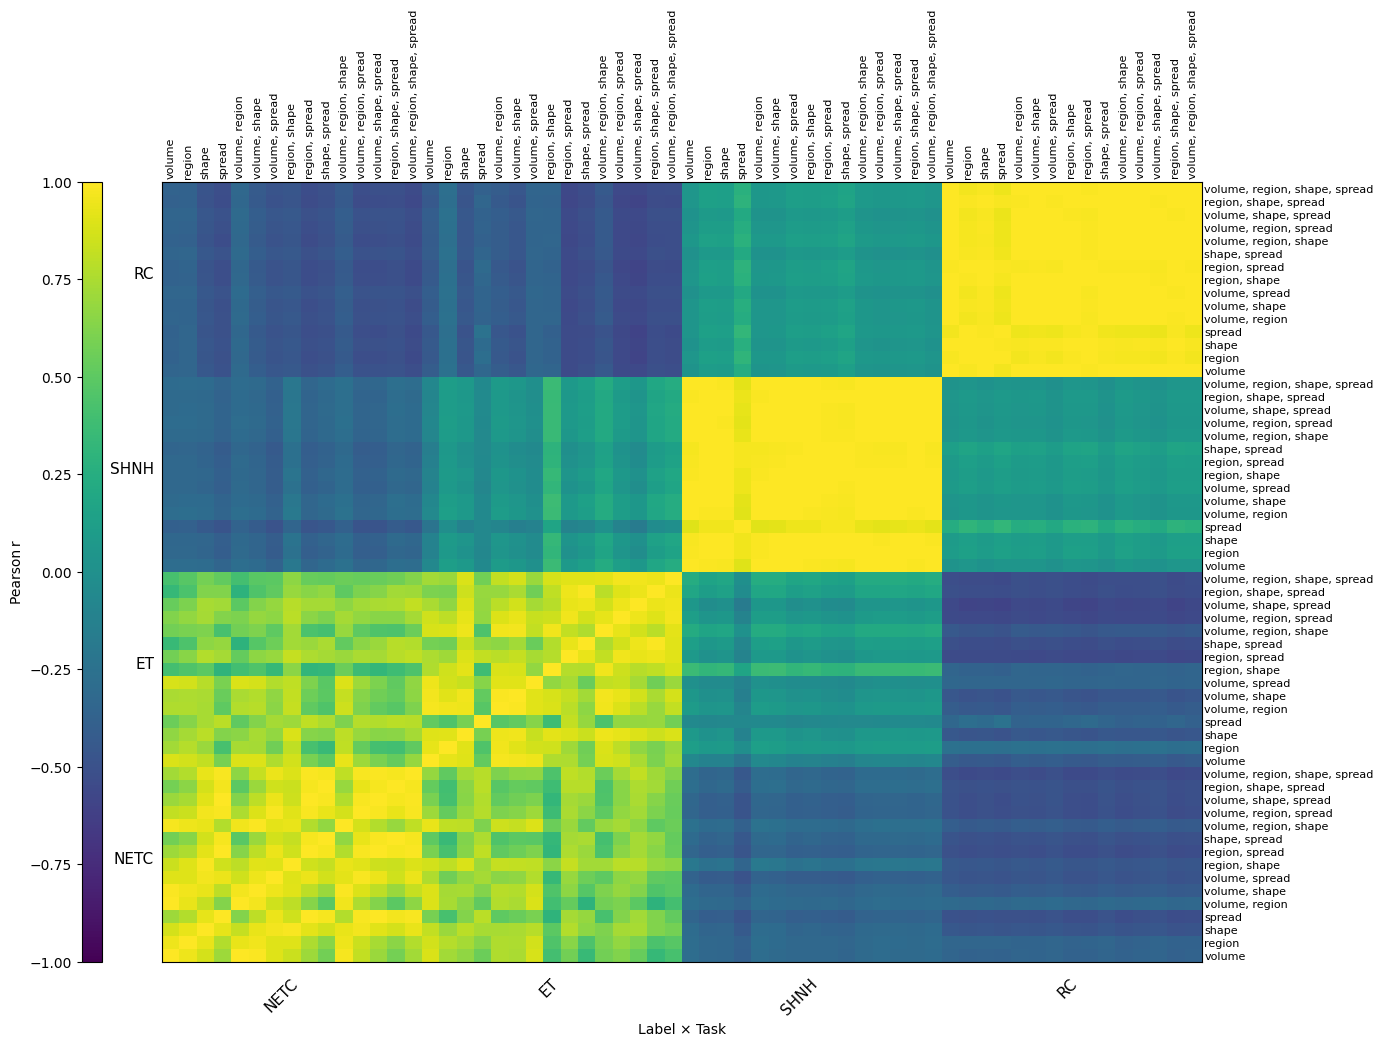

In [60]:
fig, ax = plt.subplots(figsize=(16, 12))

im = ax.imshow(corr, vmin=-1, vmax=1, aspect='auto', origin='lower')

# ------------------------------------------------------------------
# >>> 1.  data containers
# ------------------------------------------------------------------
group_size   = 15
centres      = np.arange(group_size/2, 60, group_size)    # [7.5, 22.5, 37.5, 52.5]

# short group names (match your first screenshot)
group_labels = ['NETC', 'ET', 'SHNH', 'RC']

task_labels_base = [
    "volume", "region", "shape", "spread",
    "volume, region", "volume, shape", "volume, spread",
    "region, shape", "region, spread", "shape, spread",
    "volume, region, shape", "volume, region, spread",
    "volume, shape, spread", "region, shape, spread",
    "volume, region, shape, spread"
]
task_labels = task_labels_base * 4   # repeat → 60 items

# ------------------------------------------------------------------
# >>> 2.  assign MAJOR ticks  (label groups)
# ------------------------------------------------------------------
ax.set_xticks(centres, minor=False)
ax.set_yticks(centres, minor=False)

ax.set_xticklabels(group_labels, rotation=45, ha='right', fontsize=11, minor=False)
ax.set_yticklabels(group_labels, fontsize=11, minor=False)

# show majors only on bottom & left
ax.tick_params(axis='x', which='major',
               labelbottom=True, labeltop=False,
               bottom=True, top=False, pad=10, length=0)

ax.tick_params(axis='y', which='major',
               labelleft=True, labelright=False,
               left=True, right=False, pad=6, length=0)

# ------------------------------------------------------------------
# >>> 3.  assign MINOR ticks  (task combinations)
# ------------------------------------------------------------------
ax.set_xticks(np.arange(60), minor=True)
ax.set_yticks(np.arange(60), minor=True)

ax.set_xticklabels(task_labels, rotation=90, fontsize=8, minor=True)
ax.set_yticklabels(task_labels, fontsize=8, minor=True)

# show minors only on top & right
ax.tick_params(axis='x', which='minor',
               labelbottom=False, labeltop=True,
               bottom=False, top=True, pad=2, length=0)

ax.tick_params(axis='y', which='minor',
               labelleft=False, labelright=True,
               left=False, right=True, pad=2, length=0)

# ------------------------------------------------------------------
# >>> 4.  cosmetics
# ------------------------------------------------------------------
ax.set_xlabel('Label × Task')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
# "left",  size=2% of main image,  pad = 0.5 cm gap
cax = divider.append_axes("left", size="2%", pad=0.6)     

cb = fig.colorbar(im, cax=cax, label='Pearson r')
cb.ax.yaxis.set_label_position('left')   # label on left of the bar
cb.ax.yaxis.tick_left()

# ------------------------------------------------------------
# 2.  Because we stole space on the left, widen the overall layout a bit
# ------------------------------------------------------------
plt.subplots_adjust(left=0.28, bottom=0.23, right=0.95, top=0.88)

# give Matplotlib a bit more room so long labels don’t clip
plt.subplots_adjust(bottom=0.23, left=0.23, right=0.93, top=0.88)
plt.savefig("block_wts_corr_heatmap.png")
plt.show()

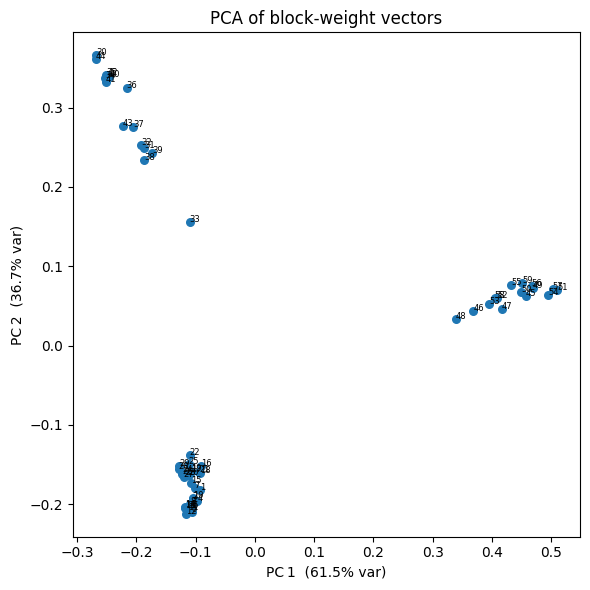

In [43]:
# ------------------------------------------------------------------
# 6 .  2‑D PCA scatter (quick visual clustering check)  ----------------------
# ------------------------------------------------------------------
pca   = PCA(n_components=2)
emb   = pca.fit_transform(weights)            # shape (N,2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(emb[:, 0], emb[:, 1], s=30)
for i, txt in enumerate(prompts):             # label with row number to avoid clutter
    ax.annotate(str(i), (emb[i, 0], emb[i, 1]), fontsize=6)
ax.set_xlabel(f'PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA of block‑weight vectors')
plt.tight_layout()
plt.show()